<a href="https://colab.research.google.com/github/richards07-afk/Statistical-Theory/blob/main/Stats_FA9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--PROBLEM 4--

A. Regression Equation:
mpg = 37.2851 + (-5.3445)*wt

B. Regression Equation:
wt = 6.0473 + (-0.1409)*mpg



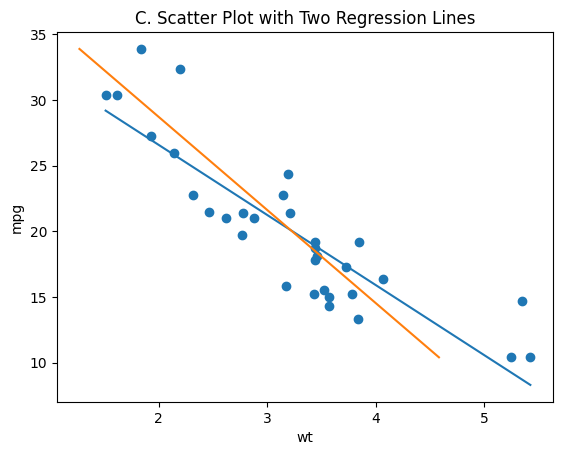

D. Interpretation:
Slope (mpg vs wt): -5.3445
→ mpg decreases as weight increases

Slope (wt vs mpg): -0.1409
→ weight decreases as mpg increases

--PROBLEM 5--



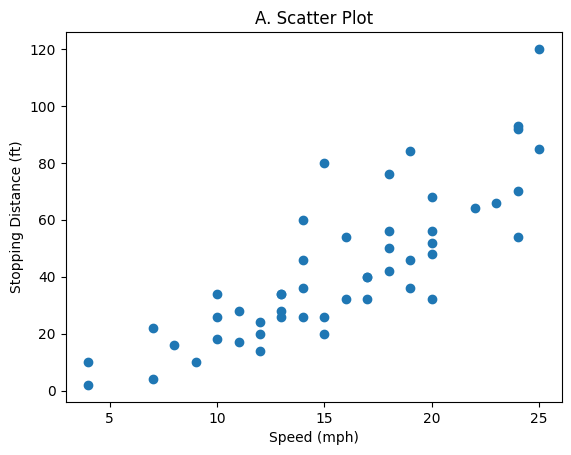

B. Quadratic Model:
D = 3.4256 + (0.6876)V + (0.1050)V^2



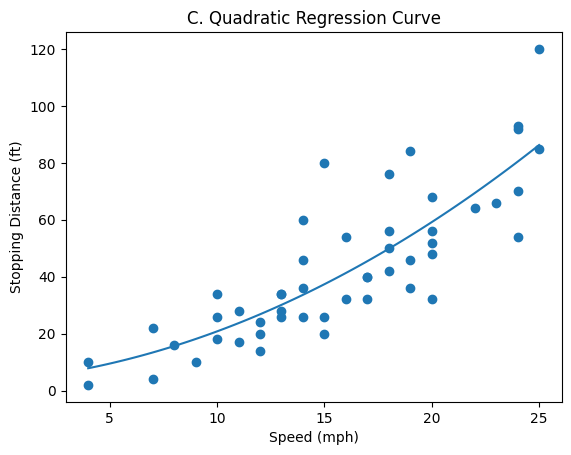

D. Estimates:
At V=45 mph: 246.98 ft
At V=80 mph: 730.38 ft

E. Linear Model:
D = -18.1211 + (3.9017)V



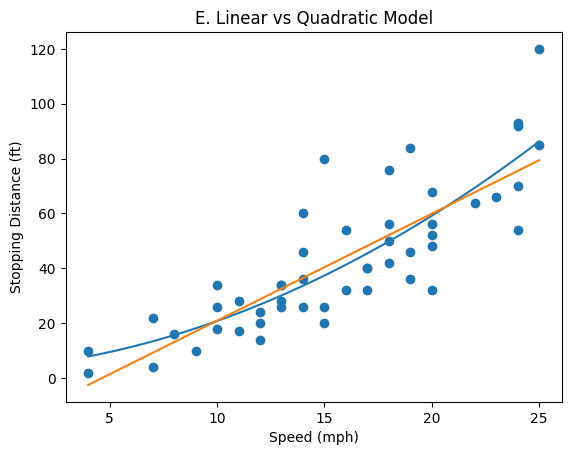

Model Comparison:
Quadratic R^2: 0.6965
Linear R^2: 0.6771


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

mtcars = pd.DataFrame({
    "mpg":[21,21,22.8,21.4,18.7,18.1,14.3,24.4,22.8,19.2,17.8,16.4,17.3,15.2,10.4,10.4,14.7,32.4,30.4,33.9,21.5,15.5,15.2,13.3,19.2,27.3,26,30.4,15.8,19.7,15,21.4],
    "wt":[2.62,2.875,2.32,3.215,3.44,3.46,3.57,3.19,3.15,3.44,3.44,4.07,3.73,3.78,5.25,5.424,5.345,2.2,1.615,1.835,2.465,3.52,3.435,3.84,3.845,1.935,2.14,1.513,3.17,2.77,3.57,2.78]
})

wt = mtcars['wt']
mpg = mtcars['mpg']

X1 = sm.add_constant(wt)
model1 = sm.OLS(mpg, X1).fit()

print("--PROBLEM 4--\n")
print("A. Regression Equation:")
print(f"mpg = {model1.params.iloc[0]:.4f} + ({model1.params.iloc[1]:.4f})*wt\n")

X2 = sm.add_constant(mpg)
model2 = sm.OLS(wt, X2).fit()

print("B. Regression Equation:")
print(f"wt = {model2.params.iloc[0]:.4f} + ({model2.params.iloc[1]:.4f})*mpg\n")

plt.figure()
plt.scatter(wt, mpg)

wt_vals = np.linspace(wt.min(), wt.max(), 100)
mpg_pred = model1.params.iloc[0] + model1.params.iloc[1]*wt_vals
plt.plot(wt_vals, mpg_pred)

mpg_vals = np.linspace(mpg.min(), mpg.max(), 100)
wt_pred = model2.params.iloc[0] + model2.params.iloc[1]*mpg_vals
plt.plot(wt_pred, mpg_vals)

plt.xlabel("wt")
plt.ylabel("mpg")
plt.title("C. Scatter Plot with Two Regression Lines")
plt.show()

print("D. Interpretation:")
print(f"Slope (mpg vs wt): {model1.params.iloc[1]:.4f}")
print("→ mpg decreases as weight increases\n")

print(f"Slope (wt vs mpg): {model2.params.iloc[1]:.4f}")
print("→ weight decreases as mpg increases\n")


print("--PROBLEM 5--\n")

# ✅ FIXED cars dataset (accurate R values)
cars = pd.DataFrame({
    "speed":[4,4,7,7,8,9,10,10,10,11,11,12,12,12,13,13,13,13,14,14,14,14,15,15,15,16,16,17,17,17,18,18,18,18,19,19,19,20,20,20,20,20,22,23,24,24,24,24,25,25],
    "dist":[2,10,4,22,16,10,18,26,34,17,28,14,20,24,28,26,34,34,46,26,36,60,80,20,26,54,32,40,32,40,50,42,56,76,84,36,46,68,32,48,52,56,64,66,54,70,92,93,120,85]
})

speed = cars['speed']
dist = cars['dist']

plt.figure()
plt.scatter(speed, dist)
plt.xlabel("Speed (mph)")
plt.ylabel("Stopping Distance (ft)")
plt.title("A. Scatter Plot")
plt.show()

X_quad = np.column_stack((speed, speed**2))
X_quad = sm.add_constant(X_quad)

model_quad = sm.OLS(dist, X_quad).fit()

print("B. Quadratic Model:")
print(f"D = {model_quad.params.iloc[0]:.4f} + ({model_quad.params.iloc[1]:.4f})V + ({model_quad.params.iloc[2]:.4f})V^2\n")

plt.figure()
plt.scatter(speed, dist)

s_vals = np.linspace(speed.min(), speed.max(), 100)
X_vals = sm.add_constant(np.column_stack((s_vals, s_vals**2)))
dist_pred = model_quad.predict(X_vals)

plt.plot(s_vals, dist_pred)

plt.xlabel("Speed (mph)")
plt.ylabel("Stopping Distance (ft)")
plt.title("C. Quadratic Regression Curve")
plt.show()

def predict(v):
    return model_quad.params.iloc[0] + model_quad.params.iloc[1]*v + model_quad.params.iloc[2]*(v**2)

print("D. Estimates:")
print(f"At V=45 mph: {predict(45):.2f} ft")
print(f"At V=80 mph: {predict(80):.2f} ft\n")

X_lin = sm.add_constant(speed)
model_lin = sm.OLS(dist, X_lin).fit()

print("E. Linear Model:")
print(f"D = {model_lin.params.iloc[0]:.4f} + ({model_lin.params.iloc[1]:.4f})V\n")

plt.figure()
plt.scatter(speed, dist)

plt.plot(s_vals, dist_pred)

dist_lin = model_lin.params.iloc[0] + model_lin.params.iloc[1]*s_vals
plt.plot(s_vals, dist_lin)

plt.xlabel("Speed (mph)")
plt.ylabel("Stopping Distance (ft)")
plt.title("E. Linear vs Quadratic Model")
plt.show()

print("Model Comparison:")
print(f"Quadratic R^2: {model_quad.rsquared:.4f}")
print(f"Linear R^2: {model_lin.rsquared:.4f}")